# Pythagorean Expectation for the NFL
Baseball has a famous formula that guesses a team's win % from runs scored and runs allowed. Does the same idea work in the NFL?

**win % = PF^k / (PF^k + PA^k)**  (PF = points for, PA = points against, k = a number we fit)

Steps: 1) build the data, 2) fit k, 3) test it on later seasons, 4) plot it, 5) look at lucky/unlucky teams, 6) use it for playoff odds this season.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import nfl_data_py as nfl

## 1. Data
One row per team per season: points for, points against, wins, games played.

In [2]:
# every regular season game since 1999
games = nfl.import_schedules(range(1999, 2026))
games = games[games.game_type == "REG"].dropna(subset=["home_score", "away_score"])

# each game becomes two rows, one from each team's point of view
home = games.assign(team=games.home_team, pf=games.home_score, pa=games.away_score)
away = games.assign(team=games.away_team, pf=games.away_score, pa=games.home_score)
long = pd.concat([home, away])[["season", "team", "pf", "pa"]].copy()

long["w"] = (long.pf > long.pa) + 0.5 * (long.pf == long.pa)   # a tie counts as half a win
long["gp"] = 1

# add everything up by team and season
t = long.groupby(["season", "team"], as_index=False)[["pf", "pa", "w", "gp"]].sum()
t["wpct"] = t.w / t.gp
t["x"] = np.log(t.pf / t.pa)     # this is the input for the regression, see next section
print(len(games), "games ->", len(t), "team-seasons")
t.head()

6967 games -> 861 team-seasons


,season,team,pf,pa,w,gp,wpct,x
0,1999,ARI,245.0,382.0,6.0,16,0.3750,-0.444162
1,1999,ATL,285.0,380.0,5.0,16,0.3125,-0.287682
2,1999,BAL,324.0,277.0,8.0,16,0.5000,0.156726
3,1999,BUF,320.0,229.0,11.0,16,0.6875,0.334599
4,1999,CAR,421.0,381.0,8.0,16,0.5000,0.099833


## 2. Fit k
If you take logs, the formula turns into a straight line: **logit(win %) = k * log(PF / PA)**.
So k is just the slope, and I can get it with a logistic regression (weighting each team by games played).

In [3]:
def fit(df, intercept=False):
    X = sm.add_constant(df[["x"]]) if intercept else df[["x"]]
    return sm.GLM(df.wpct, X, family=sm.families.Binomial(), freq_weights=df.gp).fit()

m0 = fit(t)                    # no intercept
m1 = fit(t, intercept=True)    # with intercept, just to check we don't need it
print(m0.summary().tables[1])
print(m1.summary().tables[1])
K = m0.params["x"]
print(f"k = {K:.3f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x              2.6657      0.069     38.798      0.000       2.531       2.800
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0128      0.018      0.709      0.478      -0.023       0.048
x              2.6661      0.069     38.809      0.000       2.531       2.801
k = 2.666


The intercept is basically 0 and not significant, so a team that scores as much as it allows really is a .500 team here. Next, how sure am I about k? Resample the team-seasons a bunch of times and refit.

In [4]:
rng = np.random.default_rng(0)
ks = []
for _ in range(500):
    resample = t.sample(len(t), replace=True, random_state=int(rng.integers(1e9)))
    ks.append(fit(resample).params["x"])

lo, hi = np.percentile(ks, [2.5, 97.5])
print(f"k = {K:.3f}, 95% range [{lo:.3f}, {hi:.3f}]  (the number people usually quote for the NFL is 2.37)")

k = 2.666, 95% range [2.568, 2.767]  (the number people usually quote for the NFL is 2.37)


## 3. Does it work on seasons it hasn't seen?
Fit on 1999-2019, then predict 2020-2025 and see how many wins off it is per team.

In [5]:
train = t[t.season <= 2019]
test = t[t.season >= 2020]
k_train = fit(train).params["x"]

def expected_wins(df, k):
    return df.gp * df.pf**k / (df.pf**k + df.pa**k)

def miss(pred, actual):
    err = pred - actual
    return pd.Series({"avg miss (wins)": err.abs().mean(), "RMSE": np.sqrt((err**2).mean())})

pd.DataFrame({
    f"my k = {k_train:.2f}": miss(expected_wins(test, k_train), test.w),
    "k = 2.37": miss(expected_wins(test, 2.37), test.w),
    "k = 1.83 (baseball)": miss(expected_wins(test, 1.83), test.w),
    "everyone at .500": miss(test.gp / 2, test.w),
}).T.round(3)

,avg miss (wins),RMSE
my k = 2.62,1.111,1.411
k = 2.37,1.158,1.458
k = 1.83 (baseball),1.357,1.673
everyone at .500,2.656,3.193


## 4. Plots

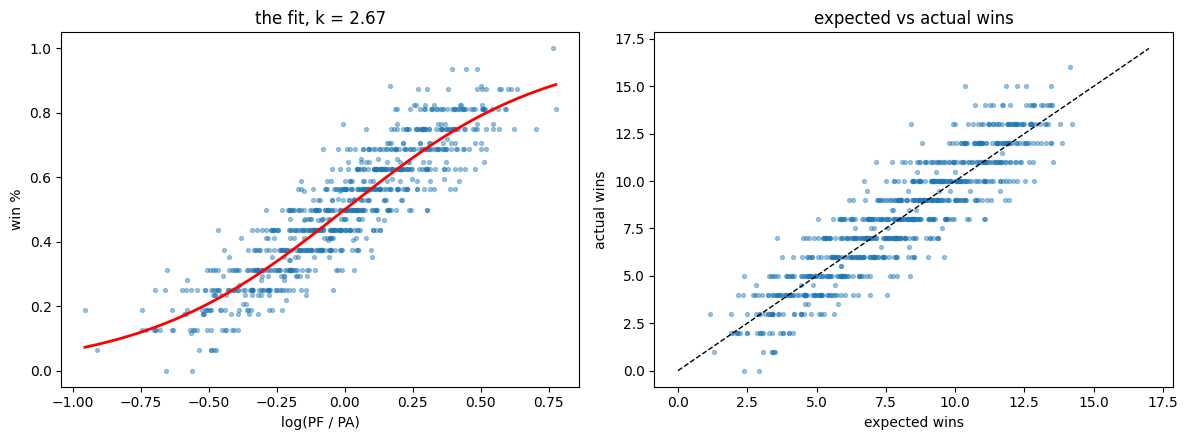

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

xs = np.linspace(t.x.min(), t.x.max(), 200)
ax[0].scatter(t.x, t.wpct, s=8, alpha=0.4)
ax[0].plot(xs, 1 / (1 + np.exp(-K * xs)), "r", lw=2)
ax[0].set(xlabel="log(PF / PA)", ylabel="win %", title=f"the fit, k = {K:.2f}")

t["exp_w"] = expected_wins(t, K)
ax[1].scatter(t.exp_w, t.w, s=8, alpha=0.4)
ax[1].plot([0, 17], [0, 17], "k--", lw=1)
ax[1].set(xlabel="expected wins", ylabel="actual wins", title="expected vs actual wins")

plt.tight_layout()
plt.show()

## 5. Lucky and unlucky teams
Actual wins minus expected wins. Big positives are teams that won more than their points say they should have.

In [7]:
t["diff"] = t.w - t.exp_w
cols = ["season", "team", "pf", "pa", "w", "exp_w", "diff"]
print("luckiest")
display(t.sort_values("diff", ascending=False)[cols].head(10).round(2))
print("unluckiest")
display(t.sort_values("diff")[cols].head(10).round(2))

luckiest


,season,team,pf,pa,w,exp_w,diff
812,2024,KC,385.0,326.0,15.0,10.35,4.65
753,2022,MIN,424.0,427.0,13.0,8.42,4.58
426,2012,IND,357.0,387.0,11.0,7.14,3.86
396,2011,KC,212.0,338.0,7.0,3.58,3.42
719,2021,LV,374.0,439.0,10.0,6.71,3.29
676,2020,CLE,408.0,419.0,11.0,7.72,3.28
684,2020,KC,473.0,362.0,14.0,10.74,3.26
564,2016,OAK,416.0,385.0,12.0,8.82,3.18
181,2004,PIT,372.0,251.0,15.0,11.85,3.15
648,2019,GB,376.0,313.0,13.0,9.92,3.08


unluckiest


,season,team,pf,pa,w,exp_w,diff
844,2025,KC,362.0,328.0,6.0,9.61,-3.61
670,2020,ATL,396.0,414.0,4.0,7.53,-3.53
86,2001,SD,332.0,321.0,5.0,8.36,-3.36
235,2006,JAX,371.0,274.0,8.0,11.07,-3.07
645,2019,DAL,434.0,321.0,8.0,11.05,-3.05
296,2008,GB,419.0,380.0,6.0,9.04,-3.04
319,2009,BAL,391.0,261.0,9.0,11.94,-2.94
580,2017,CLE,234.0,410.0,0.0,2.93,-2.93
852,2025,NYG,381.0,439.0,4.0,6.91,-2.91
186,2004,TB,301.0,304.0,5.0,7.89,-2.89


Does the luck carry over? If it were skill, a team that beat its expected wins this year would do it again next year.

In [8]:
nxt = t[["season", "team", "diff"]].copy()
nxt["season"] -= 1                       # line up each season with the one after it
both = t.merge(nxt, on=["season", "team"], suffixes=("", "_next"))
print("correlation of this year's luck with next year's:", round(both["diff"].corr(both["diff_next"]), 3))

correlation of this year's luck with next year's: 0.003


## 6. Playoff odds for this season
Plan: get a rating for every team from its points so far, turn ratings into a win chance for every remaining game, play the rest of the season out 10,000 times, and see who makes the playoffs in each one.

- **Rating** = k * log(PF / PA) using this season's points so far. Only a few games in, that's really noisy, so I add 8 pretend games where the team scored and allowed exactly the league average. That pulls early ratings back toward average.
- **Game win chance:** if two teams have ratings, the chance the first one wins is the logistic of the difference (this is the "log5" idea from baseball). Then I add a home-field bump, taken from how often home teams have actually won.
- **Playoffs:** 4 division winners + 3 wild cards per conference. Ties in the standings are just broken randomly (the real tiebreakers are complicated, so close races are approximate).
- Ratings stay fixed while the season is simulated, so this is a snapshot that gets better each week you rerun it.

In [9]:
season = 2026
sched = nfl.import_schedules([season])
sched = sched[sched.game_type == "REG"].reset_index(drop=True)

# nfl_data_py can lag a day or so behind, so fill in newer final scores from ESPN's public scoreboard feed
# (the same data that's behind espn.com/nfl/schedule). If ESPN can't be reached, I just use nfl_data_py as is.
import json, urllib.request
ESPN_FIX = {"WSH": "WAS", "LAR": "LA"}        # the two abbreviations ESPN spells differently from nflverse

def espn_finals(season, weeks):
    rows = []
    for wk in weeks:
        url = f"https://site.api.espn.com/apis/site/v2/sports/football/nfl/scoreboard?week={wk}&seasontype=2&dates={season}"
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        for e in json.load(urllib.request.urlopen(req, timeout=20))["events"]:
            comp = e["competitions"][0]
            if not comp["status"]["type"]["completed"]:
                continue
            side = {c["homeAway"]: c for c in comp["competitors"]}
            abbr = lambda c: ESPN_FIX.get(c["team"]["abbreviation"], c["team"]["abbreviation"])
            rows.append({"week": wk, "away_team": abbr(side["away"]), "home_team": abbr(side["home"]),
                         "home_score_espn": float(side["home"]["score"]), "away_score_espn": float(side["away"]["score"])})
    return pd.DataFrame(rows)

try:
    started = sched[sched.gameday <= pd.Timestamp.today().strftime("%Y-%m-%d")]
    check = sorted(set(started[started.home_score.isna()].week))           # weeks with games that should be done but have no score yet
    fin = espn_finals(season, check)
    if len(fin):
        sched = sched.merge(fin, on=["week", "away_team", "home_team"], how="left")
        new_scores = sched.home_score.isna() & sched.home_score_espn.notna()
        sched["home_score"] = sched.home_score.fillna(sched.home_score_espn)
        sched["away_score"] = sched.away_score.fillna(sched.away_score_espn)
        sched = sched.drop(columns=["home_score_espn", "away_score_espn"])
        print(f"filled in {int(new_scores.sum())} newer final scores from ESPN")
    else:
        print("no newer final scores on ESPN")
except Exception as err:
    print("couldn't reach ESPN, using nfl_data_py only:", err)

done = sched.dropna(subset=["home_score", "away_score"])
todo = sched[sched.home_score.isna()]
print(f"{season}: {len(done)} games played, {len(todo)} to go")

LG = long.pf.mean()          # league average points per team per game
PHANTOM = 8

# points so far this season for each team
h = done.assign(team=done.home_team, pf=done.home_score, pa=done.away_score)
a = done.assign(team=done.away_team, pf=done.away_score, pa=done.home_score)
now = pd.concat([h, a]).groupby("team")[["pf", "pa"]].sum()
now["w"] = pd.concat([h, a]).assign(w=lambda d: (d.pf > d.pa) + 0.5 * (d.pf == d.pa)).groupby("team").w.sum()

# rating with the pretend games mixed in
now["rating"] = K * np.log((now.pf + PHANTOM * LG) / (now.pa + PHANTOM * LG))

# home-field bump: how often home teams win, in logit units
home_rate = ((games.home_score > games.away_score) + 0.5 * (games.home_score == games.away_score)).mean()
HFA = np.log(home_rate / (1 - home_rate))
print(f"home teams win {home_rate:.1%} of the time, HFA = {HFA:.2f}")

no newer final scores on ESPN
2026: 64 games played, 208 to go
home teams win 56.2% of the time, HFA = 0.25


In [10]:
# win chance for each remaining game
gap = todo.home_team.map(now.rating).values - todo.away_team.map(now.rating).values
p_home = 1 / (1 + np.exp(-(HFA + gap)))

# play the rest of the season out many times
teams = list(now.index)
idx = {tm: i for i, tm in enumerate(teams)}
nsim = 10000
home_wins = rng.random((nsim, len(todo))) < p_home        # True = home team won

wins = np.tile(now.w.values, (nsim, 1)).astype(float)
hi = todo.home_team.map(idx).values
ai = todo.away_team.map(idx).values
for j in range(len(todo)):
    wins[home_wins[:, j], hi[j]] += 1
    wins[~home_wins[:, j], ai[j]] += 1

In [11]:
# who makes the playoffs in each simulated season?
info = nfl.import_team_desc().set_index("team_abbr").loc[teams]
conf = info.team_conf.values
division = info.team_division.values

score = wins + rng.random(wins.shape) * 0.5      # tiny random number breaks ties in the standings
seed = np.zeros((nsim, len(teams)), dtype=int)   # 0 = missed playoffs, 1-7 = seed
won_div = np.zeros((nsim, len(teams)), dtype=bool)
rows = np.arange(nsim)

for c in ["AFC", "NFC"]:
    winners = []
    for d in sorted(set(division[conf == c])):
        members = np.where(division == d)[0]
        best = members[np.argmax(score[:, members], axis=1)]   # best team in the division
        won_div[rows, best] = True
        winners.append(best)
    winners = np.stack(winners, axis=1)
    winners = np.take_along_axis(winners, np.argsort(-np.take_along_axis(score, winners, 1), axis=1), 1)
    for s in range(4):
        seed[rows, winners[:, s]] = s + 1             # division winners are seeds 1-4

    members = np.where(conf == c)[0]
    rest = score[:, members].copy()
    rest[won_div[:, members]] = -1                    # division winners can't also be wild cards
    wild = np.argsort(-rest, axis=1)[:, :3]
    for s in range(3):
        seed[rows, members[wild[:, s]]] = 5 + s       # next 3 best records are seeds 5-7

odds = pd.DataFrame({
    "team": teams, "conf": conf, "wins now": now.w.values,
    "proj wins": wins.mean(0),
    "make playoffs": (seed > 0).mean(0),
    "win division": won_div.mean(0),
    "#1 seed": (seed == 1).mean(0),
}).sort_values(["conf", "make playoffs"], ascending=[True, False]).reset_index(drop=True)

odds.round(3).to_csv(f"playoff_odds_{season}.csv", index=False)
print("playoff teams per simulation (should be 14):", (seed > 0).sum(1).mean())
odds.round(3)

playoff teams per simulation (should be 14): 14.0


,team,conf,wins now,proj wins,make playoffs,win division,#1 seed
0,KC,AFC,4.0,11.651,0.933,0.650,0.341
1,JAX,AFC,3.0,11.288,0.931,0.842,0.246
2,LV,AFC,3.0,10.432,0.804,0.308,0.120
3,BUF,AFC,3.0,9.956,0.766,0.638,0.084
4,BAL,AFC,3.0,10.090,0.744,0.456,0.098
5,CIN,AFC,2.0,9.027,0.528,0.216,0.028
6,CLE,AFC,3.0,8.956,0.508,0.216,0.031
7,IND,AFC,2.0,8.424,0.402,0.141,0.015
8,NE,AFC,2.0,8.287,0.390,0.214,0.011
9,PIT,AFC,2.0,8.214,0.350,0.112,0.010


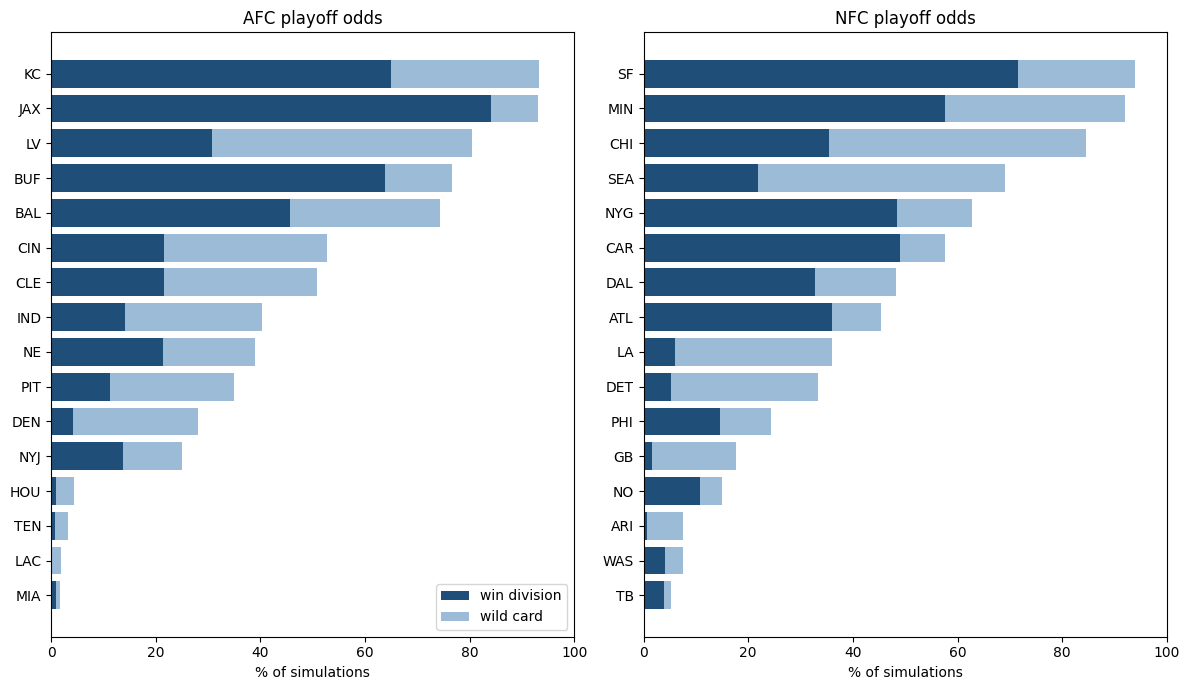

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(12, 7), sharex=True)
for ax, c in zip(axs, ["AFC", "NFC"]):
    d = odds[odds.conf == c].sort_values("make playoffs")
    ax.barh(d.team, d["win division"] * 100, color="#1f4e79", label="win division")
    ax.barh(d.team, (d["make playoffs"] - d["win division"]) * 100, left=d["win division"] * 100,
            color="#9bbbd6", label="wild card")
    ax.set(title=f"{c} playoff odds", xlabel="% of simulations", xlim=(0, 100))
axs[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Every remaining game, predicted
One picture: every game left this season, week by week. For each game the team I'm picking is in **bold**, with its win chance next to it, and the darker the box the more sure the model is. Close to white means basically a coin flip.

I'm going to save these picks now and **compare them to what actually happens once the season is over**: how many I got right, and whether the games the model was most sure about really hit more often than the toss-ups. The picks are saved in the csv named below, so they stay frozen even if I rerun the notebook later with newer games.

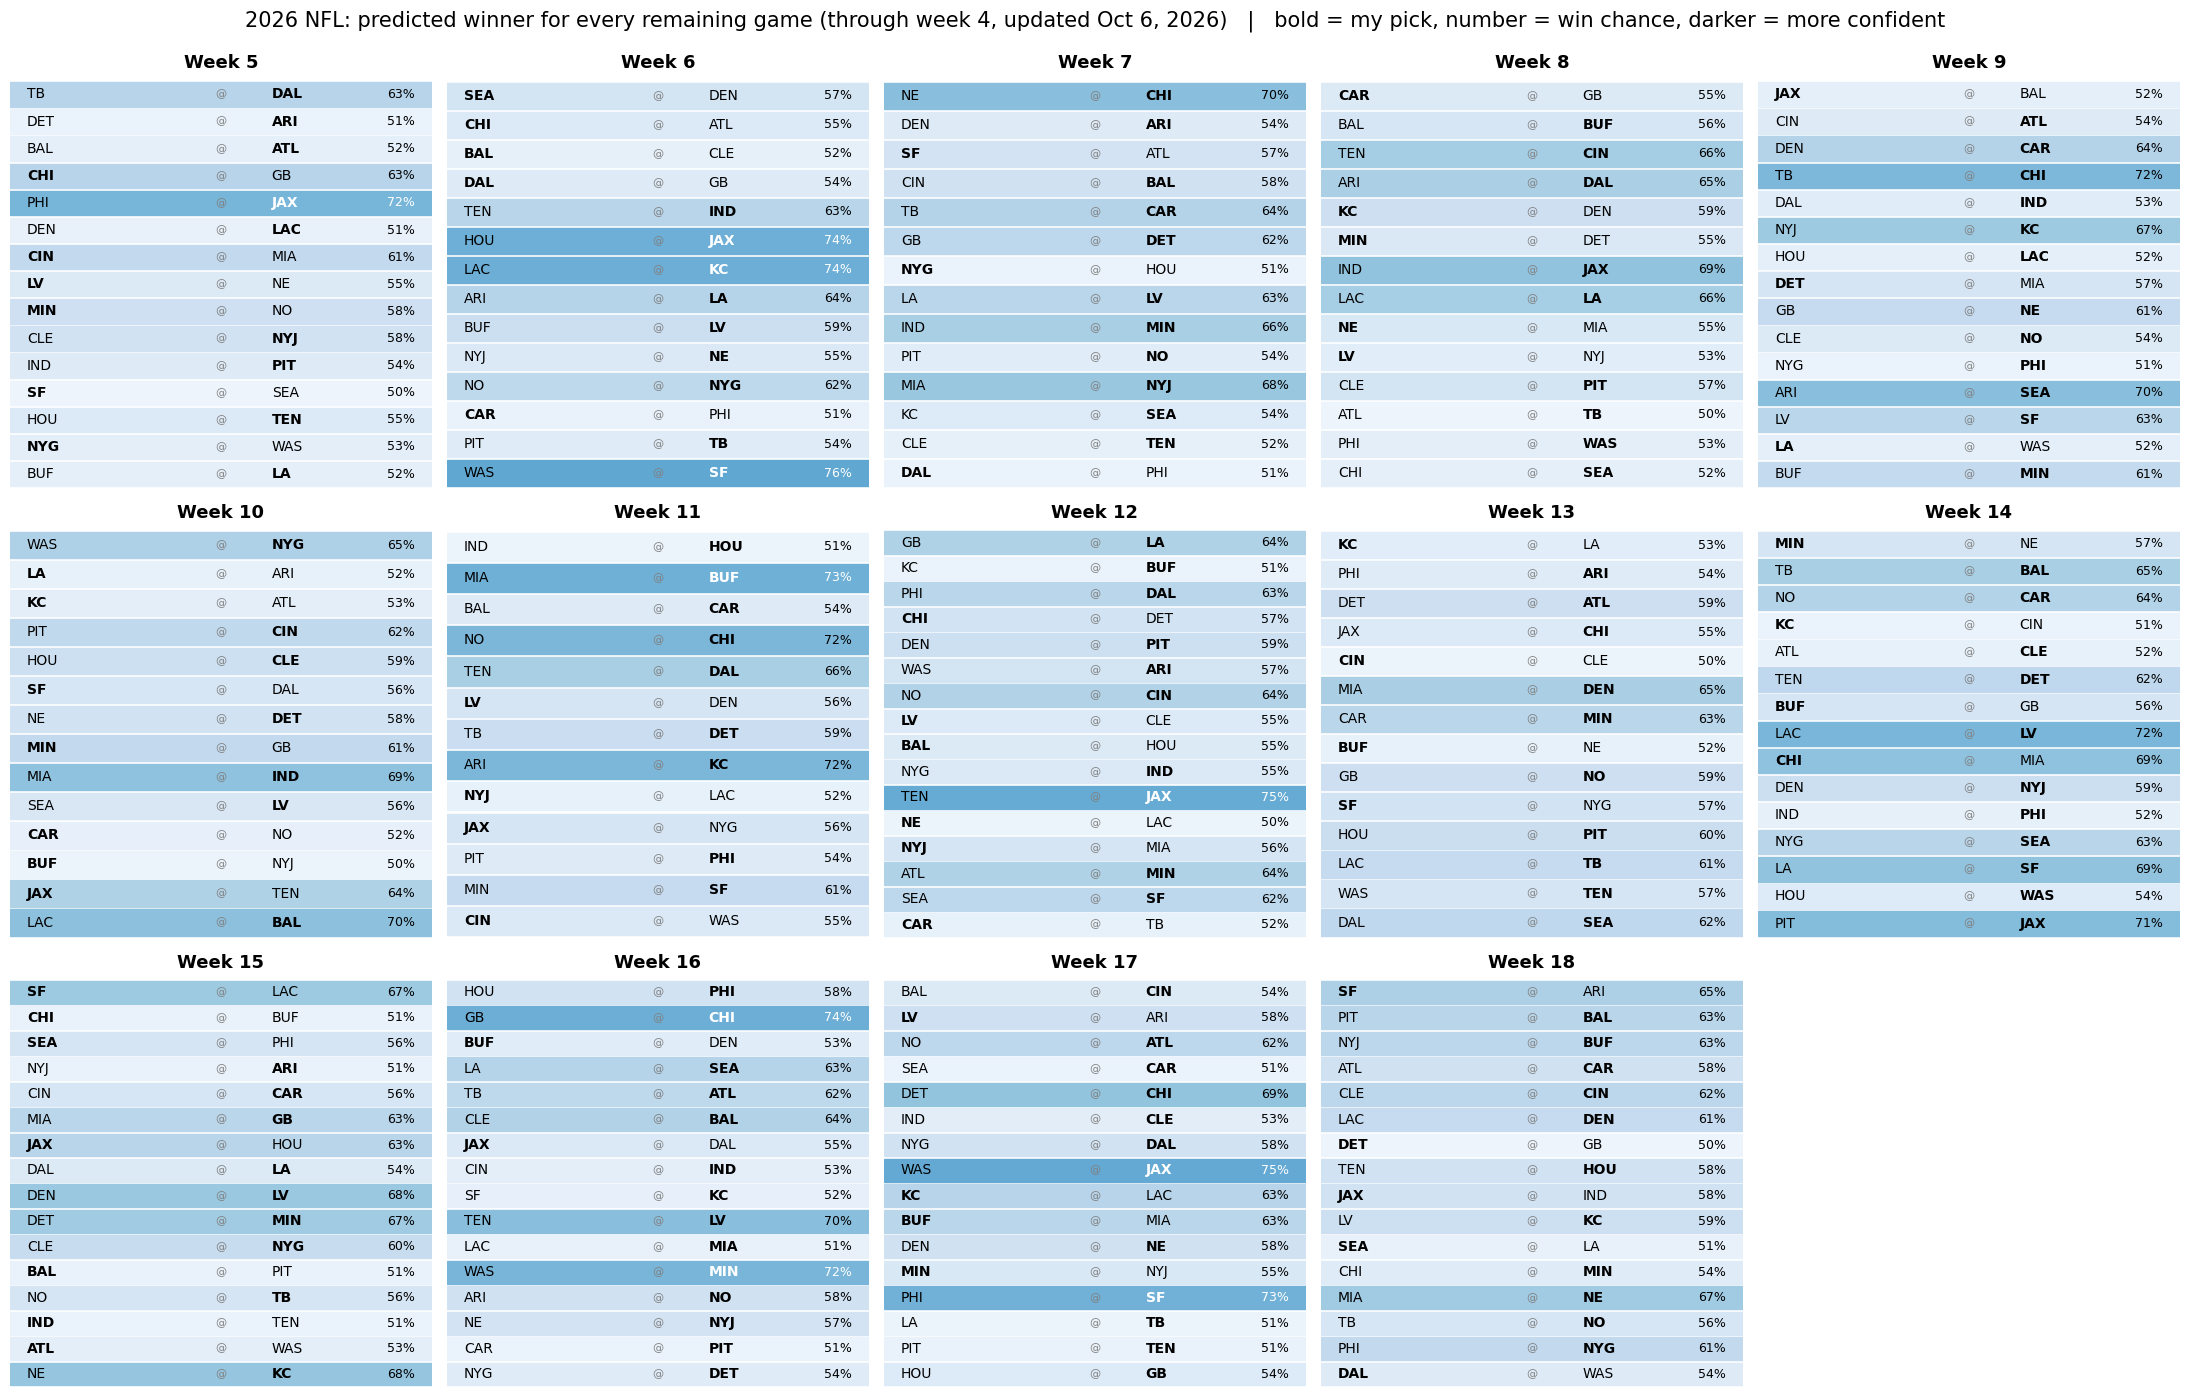

In [13]:
# last week where every game has been played (a Thursday game alone doesn't count)
full_weeks = sched.groupby("week").home_score.apply(lambda s_: s_.notna().all())
last_week = int(full_weeks[full_weeks].index.max())
today = pd.Timestamp.today().strftime("%b %-d, %Y")
snap = f"predictions_{season}_thru_week{last_week}"
picks = todo[["week", "gameday", "away_team", "home_team"]].copy()
picks["p_home"] = p_home
picks["pick"] = np.where(picks.p_home >= 0.5, picks.home_team, picks.away_team)
picks["pick_prob"] = np.maximum(picks.p_home, 1 - picks.p_home)
picks = picks.sort_values(["week", "gameday", "home_team"]).reset_index(drop=True)

# frozen copy of the predictions so I can grade them after the season
import os
if not os.path.exists(snap + ".csv"):                  # never overwrite a saved snapshot
    picks.round(3).to_csv(snap + ".csv", index=False)

GREEN, RED = "#1a7f37", "#c8553d"

def draw_board(picks, title):
    # one panel per week, one row per game; if picks has a "correct" column, mark right (check) and wrong (x) picks
    weeks = sorted(picks.week.unique())
    cmap = plt.cm.Blues
    fig, axes = plt.subplots(3, 5, figsize=(22, 14))
    for ax, wk in zip(axes.flat, weeks):
        g = picks[picks.week == wk].reset_index(drop=True)
        for i, r in g.iterrows():
            shade = cmap((r.pick_prob - 0.5) / 0.4 * 0.75 + 0.05)          # 50% -> almost white, 90% -> dark
            ax.add_patch(plt.Rectangle((0, -i - 0.5), 1, 0.9, color=shade))
            for team, x in [(r.away_team, 0.04), (r.home_team, 0.62)]:
                ax.text(x, -i - 0.05, team, ha="left", va="center", fontsize=10,
                        fontweight="bold" if team == r.pick else "normal",
                        color="white" if (team == r.pick and r.pick_prob > 0.72) else "black")
            ax.text(0.5, -i - 0.05, "@", ha="center", va="center", fontsize=8, color="gray")
            ax.text(0.96, -i - 0.05, f"{r.pick_prob:.0%}", ha="right", va="center", fontsize=9,
                    color="white" if r.pick_prob > 0.72 else "black")
            c = r.get("correct", np.nan)
            if c is True or c == True:
                ax.add_patch(plt.Rectangle((0, -i - 0.5), 1, 0.9, fill=False, edgecolor=GREEN, linewidth=2.2))
                ax.text(0.82, -i - 0.05, "✓", ha="center", va="center", fontsize=13, fontweight="bold", color=GREEN,
                        bbox=dict(boxstyle="circle,pad=0.12", fc="white", ec=GREEN, lw=1))
            elif c is False or c == False:
                ax.add_patch(plt.Rectangle((0, -i - 0.5), 1, 0.9, fill=False, edgecolor=RED, linewidth=2.2))
                ax.text(0.82, -i - 0.05, "✗", ha="center", va="center", fontsize=12, fontweight="bold", color=RED,
                        bbox=dict(boxstyle="circle,pad=0.12", fc="white", ec=RED, lw=1))
        ax.set(xlim=(0, 1), ylim=(-len(g) + 0.4, 0.6))
        ax.axis("off"); ax.set_title(f"Week {wk}", fontsize=13, fontweight="bold")
    for ax in axes.flat[len(weeks):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=15, y=0.995)
    plt.tight_layout()
    return fig

fig = draw_board(picks, f"{season} NFL: predicted winner for every remaining game (through week {last_week}, updated {today})   |   bold = my pick, number = win chance, darker = more confident")
if not os.path.exists(snap + ".png"):
    fig.savefig(snap + ".png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Scorecard: how are the picks doing?
Same picture as above, but graded. This reloads the **earliest saved snapshot** (the picks I made before those games were played) and checks them against the real final scores:
a green **✓** with a green outline means I got the game right, a red **✗** means I missed it, and no mark means the game hasn't been played yet. Games that haven't happened just stay blank.

Only games after the snapshot week can be graded, so this starts small and fills in as the season goes. It's redrawn every time I rerun the notebook.

grading picks from: predictions_2026_thru_week3.csv
10 of 16 graded picks correct (62%)


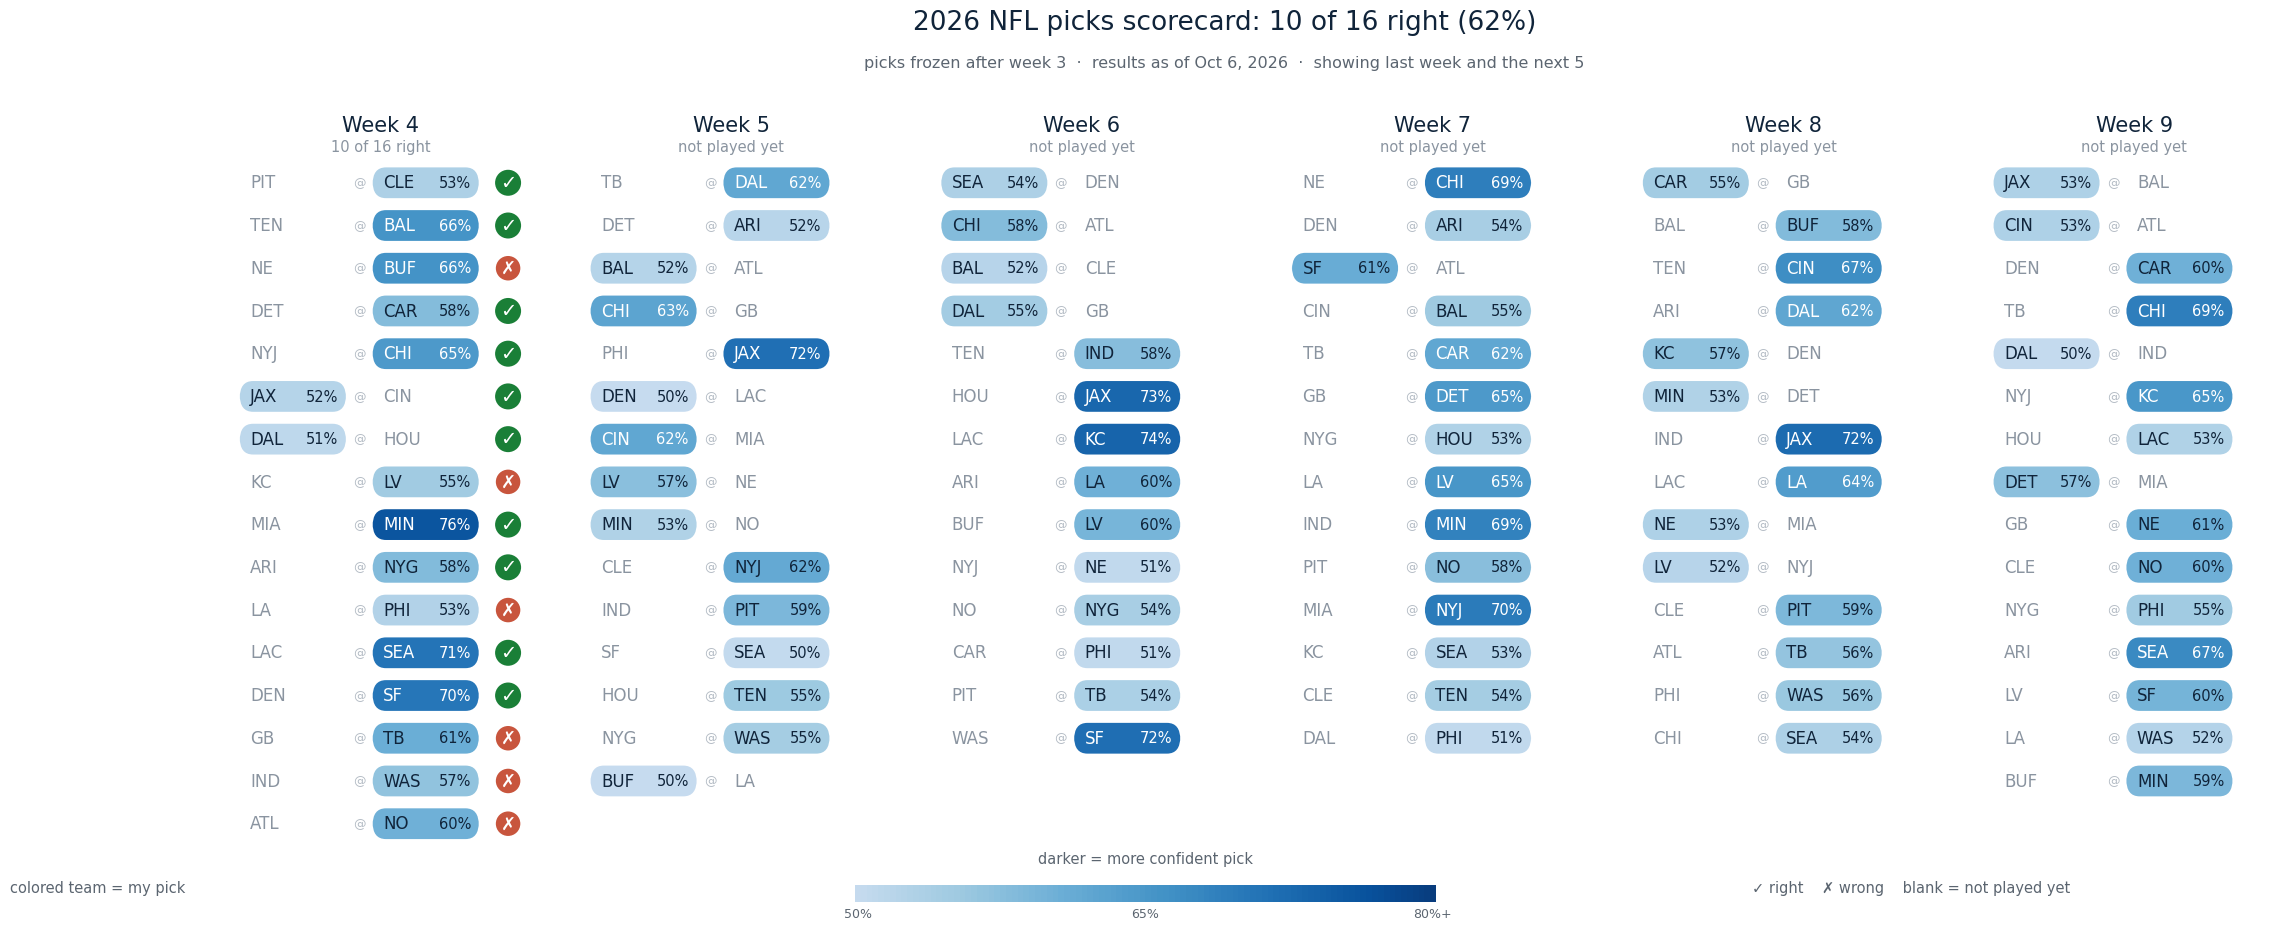

,games,right
confidence,,
50-60%,8,5.0
60-70%,5,2.0
70%+,3,3.0


In [14]:
import glob, re
snaps = sorted(glob.glob(f"predictions_{season}_thru_week*.csv"), key=lambda f: int(re.search(r"week(\d+)", f).group(1)))
frozen = pd.read_csv(snaps[0])                     # earliest snapshot = the real "before the games" picks
snap_week = int(re.search(r"week(\d+)", snaps[0]).group(1))
print("grading picks from:", snaps[0])

final = sched.dropna(subset=["home_score", "away_score"])[["week", "away_team", "home_team", "home_score", "away_score"]]
sc = frozen.merge(final, on=["week", "away_team", "home_team"], how="left")

played = sc.home_score.notna() & (sc.home_score != sc.away_score)          # ties aren't graded
winner = np.where(sc.home_score > sc.away_score, sc.home_team, sc.away_team)
sc["correct"] = pd.Series(np.where(played, sc.pick == winner, np.nan), index=sc.index).astype(object)
sc.loc[~played, "correct"] = np.nan

graded = sc[played]
hits, n = int(graded.correct.sum()), len(graded)
print(f"{hits} of {n} graded picks correct" + (f" ({hits / n:.0%})" if n else ""))

from matplotlib.patches import FancyBboxPatch

def draw_scorecard(sc, title, subtitle, n_weeks=5):
    # the most recent graded week, then the current week plus the next few, so it isn't too much at once
    open_weeks = sorted(sc[sc.correct.isna()].week.unique())
    done_weeks = sorted(set(sc[sc.correct.notna()].week.unique()) - set(open_weeks))
    weeks = done_weeks[-1:] + open_weeks[:n_weeks]
    fig, axes = plt.subplots(1, len(weeks), figsize=(4.4 * len(weeks), 9.6))
    axes = np.atleast_1d(axes)
    max_rows = sc[sc.week.isin(weeks)].groupby("week").size().max()      # same row height in every panel
    cmap = plt.cm.Blues
    conf_color = lambda p_: cmap(0.25 + min(max((p_ - 0.5) / 0.3, 0), 1) * 0.7)     # 50% = light, 80%+ = dark
    for ax, wk in zip(axes, weeks):
        g = sc[sc.week == wk].reset_index(drop=True)
        for i, r in g.iterrows():
            y = -i
            for team, x0 in [(r.away_team, 0.02), (r.home_team, 0.52)]:
                if team == r.pick:                                    # my pick gets the colored chip
                    col = conf_color(r.pick_prob)
                    ax.add_patch(FancyBboxPatch((x0, y - 0.36), 0.40, 0.72, boxstyle="round,pad=0,rounding_size=0.05",
                                                mutation_aspect=8, fc=col, ec="none"))
                    txt = "white" if r.pick_prob > 0.62 else "#10243a"
                    ax.text(x0 + 0.04, y, team, ha="left", va="center", fontsize=12, color=txt)
                    ax.text(x0 + 0.37, y, f"{r.pick_prob:.0%}", ha="right", va="center", fontsize=10.5, color=txt)
                else:
                    ax.text(x0 + 0.04, y, team, ha="left", va="center", fontsize=12, color="#8a94a0")
            ax.text(0.47, y, "@", ha="center", va="center", fontsize=9, color="#b4bcc5")
            if r.correct is True or r.correct == True:
                ax.text(1.03, y, "✓", ha="center", va="center", fontsize=14, color="white",
                        bbox=dict(boxstyle="circle,pad=0.18", fc=GREEN, ec="none"))
            elif r.correct is False or r.correct == False:
                ax.text(1.03, y, "✗", ha="center", va="center", fontsize=13, color="white",
                        bbox=dict(boxstyle="circle,pad=0.18", fc=RED, ec="none"))
        ax.set(xlim=(0, 1.1), ylim=(-max_rows + 0.4, 1.7))
        ax.axis("off")
        gr = g[g.correct.notna()]
        ax.text(0.55, 1.35, f"Week {wk}", ha="center", va="center", fontsize=15, color="#10243a")
        ax.text(0.55, 0.85, f"{int(gr.correct.sum())} of {len(gr)} right" if len(gr) else "not played yet",
                ha="center", va="center", fontsize=10.5, color="#8a94a0")

    fig.suptitle(title, fontsize=19, y=0.985, color="#10243a")
    fig.text(0.5, 0.925, subtitle, ha="center", fontsize=11.5, color="#5b6570")
    # legend: darker = more confident, plus what the marks mean
    lax = fig.add_axes([0.36, 0.055, 0.22, 0.018])
    lax.imshow(np.linspace(0.25, 0.95, 100)[None, :], cmap=cmap, vmin=0, vmax=1, aspect="auto")
    lax.set_yticks([]); lax.set_xticks([0, 49.5, 99]); lax.set_xticklabels(["50%", "65%", "80%+"], fontsize=9, color="#5b6570")
    for sp in lax.spines.values(): sp.set_visible(False)
    lax.tick_params(length=0)
    fig.text(0.47, 0.095, "darker = more confident pick", ha="center", fontsize=10.5, color="#5b6570")
    fig.text(0.70, 0.065, "✓ right    ✗ wrong    blank = not played yet", ha="left", fontsize=10.5, color="#5b6570")
    fig.text(0.04, 0.065, "colored team = my pick", ha="left", fontsize=10.5, color="#5b6570")
    return fig

fig = draw_scorecard(sc, f"{season} NFL picks scorecard: {hits} of {n} right" + (f" ({hits / n:.0%})" if n else ""),
                     f"picks frozen after week {snap_week}  ·  results as of {today}  ·  showing last week and the next 5")
fig.savefig(f"scorecard_{season}.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

# does confidence mean anything? (more useful once there are more games)
if n:
    graded = graded.assign(confidence=pd.cut(graded.pick_prob, [0.5, 0.6, 0.7, 1.0], labels=["50-60%", "60-70%", "70%+"], include_lowest=True))
    display(graded.groupby("confidence", observed=True).agg(games=("correct", "size"), right=("correct", "sum")))

### Update the README
The picture in the README updates by itself whenever the image files are pushed. This cell also rewrites the little summary line under it (marked with `auto-start` / `auto-end` in the README) so the numbers in the text stay current too.

In [15]:
top = lambda c: ", ".join(f"{r.team} {r['make playoffs']:.0%}" for _, r in odds[odds.conf == c].nlargest(3, "make playoffs").iterrows())
line = (f"**Right now ({today}, through week {last_week}):** "
        + (f"{hits} of {n} graded picks right ({hits / n:.0%}). " if n else "no picks graded yet. ")
        + f"Best playoff odds: AFC {top('AFC')}; NFC {top('NFC')}.")

readme = open("README.md").read()
block = "<!-- auto-start -->\n" + line + "\n<!-- auto-end -->"
if "<!-- auto-start -->" in readme:
    readme = re.sub(r"<!-- auto-start -->.*?<!-- auto-end -->", lambda m: block, readme, flags=re.S)
    open("README.md", "w").write(readme)
    print(line)
else:
    print("README has no auto-start marker, skipping")

**Right now (Oct 6, 2026, through week 4):** 10 of 16 graded picks right (62%). Best playoff odds: AFC KC 93%, JAX 93%, LV 80%; NFC SF 94%, MIN 92%, CHI 85%.


**To do after the season:** load the predictions csv, merge it with the real final scores, and check
1. what % of games the picks got right (the model's backtest accuracy was about 60%, so that's the number to beat),
2. whether the games I gave 70%+ hit more often than the ones near 50%,
3. how the playoff odds in section 6 lined up with who actually made it.

### Last updated
Small badge showing when this notebook was last run, so anyone looking at the repo knows how fresh the numbers are. It's re-saved every time I rerun.

In [16]:
fig = plt.figure(figsize=(7.2, 1.2), dpi=150)
fig.patch.set_facecolor("white")
fig.patches.append(plt.Rectangle((0.01, 0.08), 0.98, 0.84, transform=fig.transFigure, facecolor="#eef3f8",
                                 edgecolor="#1f4e79", linewidth=1.5, joinstyle="round"))
fig.text(0.04, 0.64, "Last updated", fontsize=11, color="#5b6570", va="center")
fig.text(0.04, 0.34, today, fontsize=19, fontweight="bold", color="#1f4e79", va="center")
fig.text(0.58, 0.64, f"{season} season, through week {last_week}", fontsize=11, color="#5b6570", va="center")
fig.text(0.58, 0.34, f"{len(done)} of {len(sched)} games played", fontsize=14, color="#111418", va="center")
fig.savefig("last_updated.png", dpi=150, facecolor="white")
plt.show()

<Figure size 1080x180 with 0 Axes>